In [ ]:
# ============================================================
# Vibration-Based Condition Monitoring for Mechanical Fault Detection
# ============================================================
# Author: Askhat Bigeldiyev
#
# This notebook analyzes real-world vibration signals from the
# Case Western Reserve University (CWRU) bearing dataset.
#
# The purpose of the analysis is to demonstrate how vibration data
# can be used to distinguish between normal mechanical operation
# and faulty operating conditions.
#
# The workflow includes:
#   1. Loading vibration datasets
#   2. Extracting drive-end accelerometer signals
#   3. Visualizing each operating condition separately
#   4. Computing statistical features
#   5. Comparing fault indicators across conditions
#   6. Applying simple threshold-based anomaly detection
#
# This project is intended as a practical prototype for
# sensor-based condition monitoring and early fault detection.

In [ ]:
# Import required libraries for data loading, numerical analysis,
# statistical feature extraction, and visualization.
#
# os: used to verify uploaded files in the Colab environment.
# numpy: used for numerical operations and signal feature calculations.
# scipy.io: used to load MATLAB .mat files from the CWRU dataset.
# matplotlib: used to generate time-domain and comparison plots.
# kurtosis: used to measure the impulsiveness of vibration signals.

import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

In [ ]:
# Display the files currently available in the Colab working directory.
#
# This step verifies that all required dataset files have been uploaded
# before attempting to load them.
#
# Expected files:
#   - 97.mat      : normal baseline condition
#   - 118 2.mat  : ball fault condition
#   - 105.mat    : inner race fault condition

print(os.listdir())

['.config', '105.mat', '97.mat', '.ipynb_checkpoints', '118 2.mat', 'sample_data']


In [ ]:
# Load the normal baseline dataset.
#
# The selected file represents a healthy bearing operating under
# normal conditions. This signal is used as the reference baseline
# for later comparison against fault conditions.
#
# The file is stored in MATLAB .mat format, so scipy.io.loadmat()
# is used to read the contents.

data_normal = scipy.io.loadmat('97.mat')

# Print the internal variable names contained in the .mat file.
# This confirms which accelerometer channels and metadata are available.

print(data_normal.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X097_DE_time', 'X097_FE_time', 'X097RPM'])


In [ ]:
# Extract the drive-end accelerometer signal from the normal dataset.
#
# In the CWRU dataset:
#   DE_time refers to drive-end vibration data.
#
# The drive-end signal is selected because it is commonly used
# for bearing fault diagnostics and provides a direct measurement
# of vibration behavior near the rotating component.
#
# flatten() converts the signal from a two-dimensional column vector
# into a one-dimensional array, which is easier to process and plot.

normal_signal = data_normal['X097_DE_time'].flatten()

# Print the signal shape and first few values to verify successful extraction.

print(normal_signal.shape)
print(normal_signal[:5])

(243938,)
[ 0.05319692  0.08866154  0.09971815  0.05862092 -0.00458954]


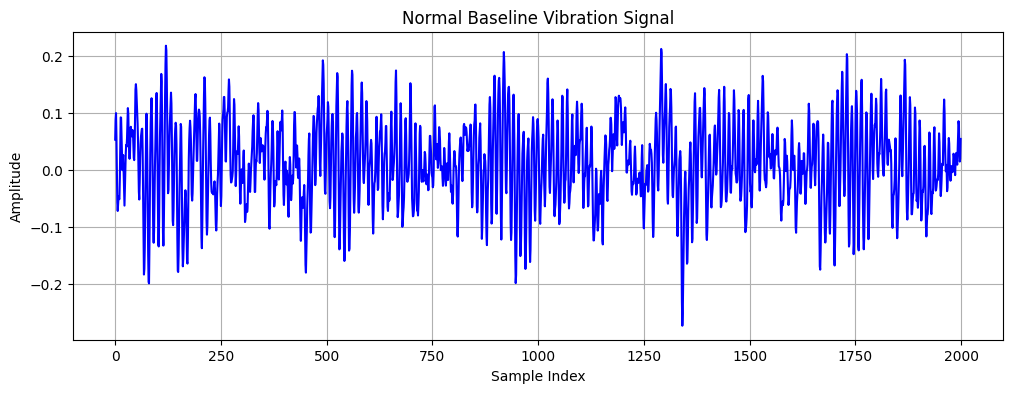

In [ ]:
# Visualize the first 2,000 samples of the normal baseline vibration signal.
#
# Plotting a limited segment makes the waveform easier to inspect visually.
# The normal signal is expected to show relatively stable amplitude behavior
# without large impulsive spikes or irregular disturbances.
#
# This plot establishes the baseline vibration pattern for comparison.

plt.figure(figsize=(12,4))
plt.plot(normal_signal[:2000], color='blue')

plt.title('Normal Baseline Vibration Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)

plt.show()

In [ ]:
# Load the ball fault dataset.
#
# This dataset represents a bearing with a localized defect on the rolling
# element (ball). It is used as the first fault condition for comparison
# against the normal baseline.
#
# The selected fault file corresponds to the same general operating load
# condition as the baseline, which helps make the comparison more controlled.

data_ball = scipy.io.loadmat('118 2.mat')

# Print available variables to confirm the correct drive-end signal key.

print(data_ball.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X118_DE_time', 'X118_FE_time', 'X118_BA_time', 'X118RPM'])


In [ ]:
# Extract the drive-end vibration signal for the ball fault condition.
#
# This signal is expected to contain abnormal vibration characteristics
# caused by the localized defect in the rolling element.
#
# As with the normal condition, flatten() converts the signal into a
# one-dimensional array for consistent processing.

ball_signal = data_ball['X118_DE_time'].flatten()

# Verify signal length and inspect the first few values.

print(ball_signal.shape)
print(ball_signal[:5])

(122571,)
[-0.0027614  -0.09632403  0.11370459  0.25729725 -0.05831421]


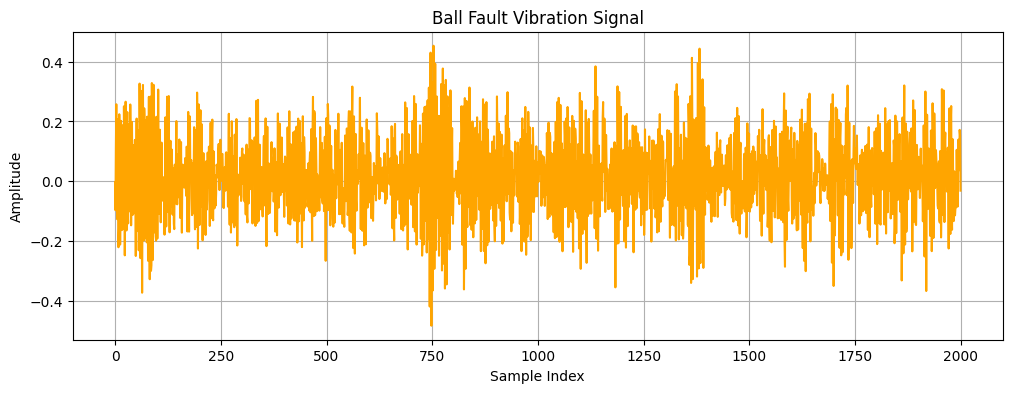

In [ ]:
# Visualize the ball fault vibration signal separately.
#
# A separate plot helps avoid visual compression that occurs when multiple
# signals are plotted together. This makes it easier to inspect amplitude
# variation, irregularity, and possible impulsive behavior.
#
# Compared to the normal signal, the fault signal is expected to show
# increased vibration energy and less stable waveform behavior.

plt.figure(figsize=(12,4))
plt.plot(ball_signal[:2000], color='orange')

plt.title('Ball Fault Vibration Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)

plt.show()

In [ ]:
# Load the inner race fault dataset.
#
# This dataset represents a bearing with a localized defect on the inner race.
# Inner race faults often produce stronger and more impulsive vibration
# responses compared to smaller or less severe defects.
#
# Including this second fault condition strengthens the analysis by showing
# that the feature extraction approach can detect more than one fault type.

data_ir = scipy.io.loadmat('105.mat')

# Print available variables to confirm the correct drive-end signal key.

print(data_ir.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X105_DE_time', 'X105_FE_time', 'X105_BA_time', 'X105RPM'])


In [ ]:
# Extract the drive-end vibration signal for the inner race fault condition.
#
# This signal is used to evaluate whether the same feature-based monitoring
# approach can identify a different mechanical fault mode.
#
# The signal is flattened to maintain the same format used for the normal
# and ball fault signals.

ir_signal = data_ir['X105_DE_time'].flatten()

# Verify successful extraction.

print(ir_signal.shape)
print(ir_signal[:5])

(121265,)
[-0.08300435 -0.19573433  0.23341928  0.10395848 -0.18111517]


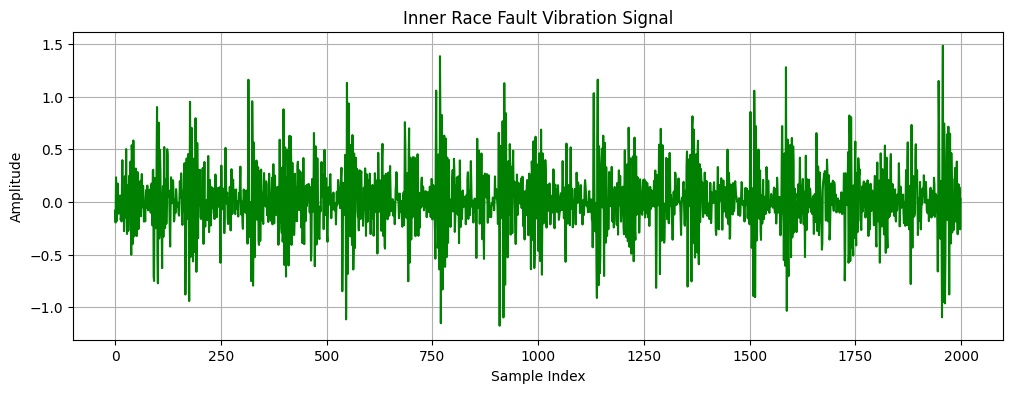

In [ ]:
# Visualize the inner race fault vibration signal separately.
#
# The inner race fault signal is expected to show higher amplitude variations
# and more pronounced spikes, which are typical indicators of mechanical
# impact or localized damage.
#
# Plotting this condition separately allows its behavior to be evaluated
# without being visually masked by other signals.

plt.figure(figsize=(12,4))
plt.plot(ir_signal[:2000], color='green')

plt.title('Inner Race Fault Vibration Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)

plt.show()

In [ ]:
# Define a reusable feature extraction function.
#
# This function computes statistical features commonly used in vibration-based
# condition monitoring. Using a function ensures that the same calculations
# are applied consistently to every operating condition.
#
# Feature definitions:
#   RMS       : Measures overall vibration energy.
#   Mean      : Average signal amplitude.
#   STD       : Measures signal variability around the mean.
#   Variance  : Measures dispersion and instability in the signal.
#   Max / Min : Capture peak positive and negative amplitudes.
#   Kurtosis  : Measures impulsiveness; higher values may indicate spikes
#               caused by localized mechanical defects.

def compute_features(signal):
    """
    Compute statistical features for a vibration signal.

    Parameters:
        signal (numpy.ndarray): One-dimensional vibration signal.

    Returns:
        dict: Dictionary containing statistical features.
    """
    return {
        "RMS": np.sqrt(np.mean(signal**2)),
        "Mean": np.mean(signal),
        "STD": np.std(signal),
        "Variance": np.var(signal),
        "Max": np.max(signal),
        "Min": np.min(signal),
        "Kurtosis": kurtosis(signal)
    }

In [ ]:
# Compute statistical features for all three operating conditions:
#   1. Normal baseline
#   2. Ball fault
#   3. Inner race fault
#
# These features allow quantitative comparison between healthy and faulty
# mechanical states. In fault conditions, RMS, variance, and kurtosis are
# expected to increase due to higher vibration energy and impulsive behavior.

features_normal = compute_features(normal_signal)
features_ball = compute_features(ball_signal)
features_ir = compute_features(ir_signal)

print("Normal:", features_normal)
print("Ball Fault:", features_ball)
print("Inner Race Fault:", features_ir)

Normal: {'RMS': np.float64(0.07376396805784112), 'Mean': np.float64(0.012558211199945506), 'STD': np.float64(0.0726870986839877), 'Variance': np.float64(0.005283414315095767), 'Max': np.float64(0.31125415384615385), 'Min': np.float64(-0.28663753846153844), 'Kurtosis': np.float64(-0.2357572095605085)}
Ball Fault: {'RMS': np.float64(0.13923355755837466), 'Mean': np.float64(0.012607048538945315), 'STD': np.float64(0.13866162366530224), 'Variance': np.float64(0.019227045877497906), 'Max': np.float64(0.6039338123752496), 'Min': np.float64(-0.6070200798403194), 'Kurtosis': np.float64(-0.015283977273415683)}
Inner Race Fault: {'RMS': np.float64(0.29152604538898663), 'Mean': np.float64(0.013443559443270714), 'STD': np.float64(0.2912159093347009), 'Variance': np.float64(0.08480670584963673), 'Max': np.float64(1.739030499001996), 'Min': np.float64(-1.3798864271457085), 'Kurtosis': np.float64(2.395863773038575)}


In [ ]:
# Create a structured feature comparison table.
#
# A table makes it easier to compare feature values across conditions
# and provides a clear summary for the technical report.
#
# This table can also be exported or included in project documentation.

import pandas as pd

feature_table = pd.DataFrame([
    {"Condition": "Normal", **features_normal},
    {"Condition": "Ball Fault", **features_ball},
    {"Condition": "Inner Race Fault", **features_ir}
])

feature_table

,Condition,RMS,Mean,STD,Variance,Max,Min,Kurtosis
0,Normal,0.073764,0.012558,0.072687,0.005283,0.311254,-0.286638,-0.235757
1,Ball Fault,0.139234,0.012607,0.138662,0.019227,0.603934,-0.607020,-0.015284
2,Inner Race Fault,0.291526,0.013444,0.291216,0.084807,1.739030,-1.379886,2.395864


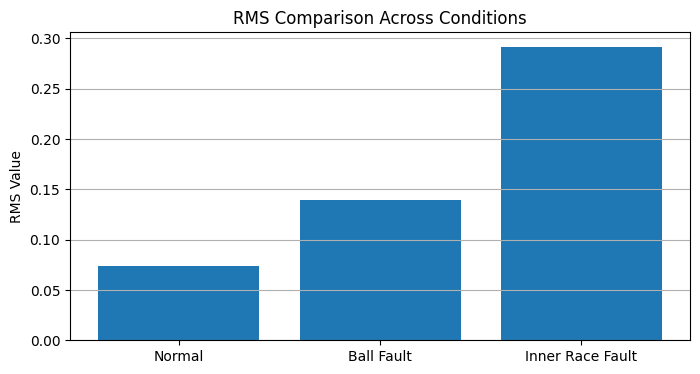

In [ ]:
# Plot RMS values across operating conditions.
#
# RMS is one of the most important indicators in vibration analysis because
# it reflects the overall energy content of the signal.
#
# A higher RMS value generally indicates stronger vibration activity,
# which may be associated with mechanical degradation or fault conditions.

plt.figure(figsize=(8,4))
plt.bar(feature_table["Condition"], feature_table["RMS"])

plt.title('RMS Comparison Across Conditions')
plt.ylabel('RMS Value')
plt.grid(axis='y')

plt.show()

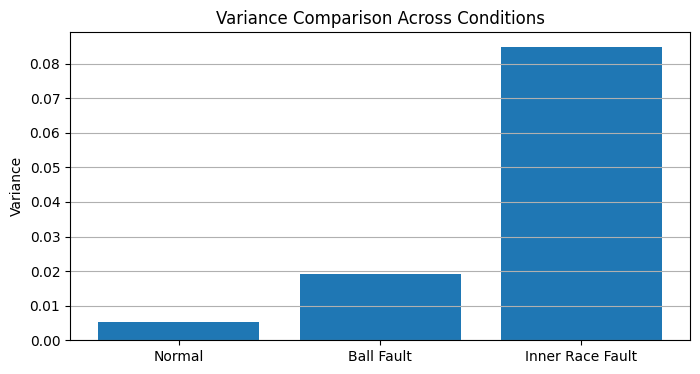

In [ ]:
# Plot variance values across operating conditions.
#
# Variance measures how widely the vibration signal fluctuates around
# its mean value. Faulty mechanical conditions often produce higher variance
# because defects introduce irregular impacts and unstable motion.
#
# Comparing variance helps quantify the increase in signal instability.

plt.figure(figsize=(8,4))
plt.bar(feature_table["Condition"], feature_table["Variance"])

plt.title('Variance Comparison Across Conditions')
plt.ylabel('Variance')
plt.grid(axis='y')

plt.show()

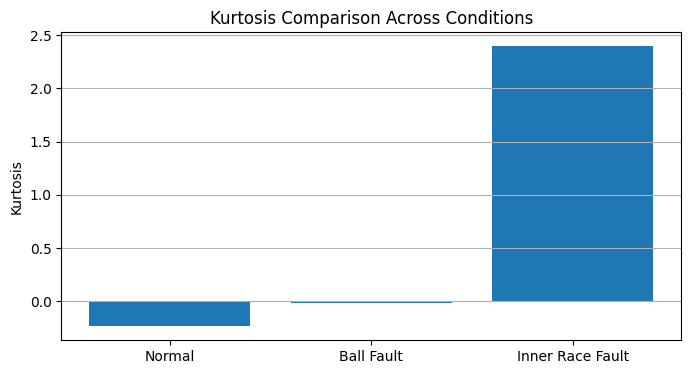

In [ ]:
# Plot kurtosis values across operating conditions.
#
# Kurtosis is useful in fault diagnostics because it captures the degree
# of impulsiveness in a signal. Localized bearing defects often create
# sharp vibration impulses, which can increase kurtosis.
#
# This feature helps identify whether the signal contains abnormal spikes
# beyond normal vibration behavior.

plt.figure(figsize=(8,4))
plt.bar(feature_table["Condition"], feature_table["Kurtosis"])

plt.title('Kurtosis Comparison Across Conditions')
plt.ylabel('Kurtosis')
plt.grid(axis='y')

plt.show()

In [ ]:
# Perform simple threshold-based anomaly detection.
#
# The threshold is defined using the RMS value of the normal baseline signal:
#
#     threshold = 2 × RMS(normal)
#
# Any sample whose absolute amplitude exceeds this threshold is counted
# as an anomalous point.
#
# This method is intentionally simple and interpretable. It does not attempt
# to replace advanced machine learning models, but it demonstrates how a
# baseline condition can be used to identify abnormal vibration behavior.

threshold = features_normal["RMS"] * 2

normal_anomalies = np.sum(np.abs(normal_signal) > threshold)
ball_anomalies = np.sum(np.abs(ball_signal) > threshold)
ir_anomalies = np.sum(np.abs(ir_signal) > threshold)

print("Threshold:", threshold)
print("Normal anomalies:", normal_anomalies)
print("Ball Fault anomalies:", ball_anomalies)
print("Inner Race Fault anomalies:", ir_anomalies)

Threshold: 0.14752793611568224
Normal anomalies: 10344
Ball Fault anomalies: 35618
Inner Race Fault anomalies: 60649


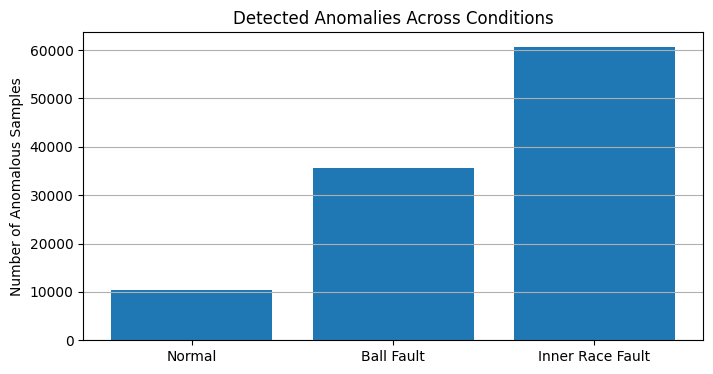

In [ ]:
# Visualize the number of detected anomalous samples across conditions.
#
# This chart provides a clear summary of how often each signal exceeds
# the baseline-derived anomaly threshold.
#
# A higher anomaly count in fault conditions supports the conclusion that
# vibration-based features can distinguish abnormal mechanical behavior
# from normal operation.

conditions = ["Normal", "Ball Fault", "Inner Race Fault"]
anomaly_counts = [normal_anomalies, ball_anomalies, ir_anomalies]

plt.figure(figsize=(8,4))
plt.bar(conditions, anomaly_counts)

plt.title('Detected Anomalies Across Conditions')
plt.ylabel('Number of Anomalous Samples')
plt.grid(axis='y')

plt.show()

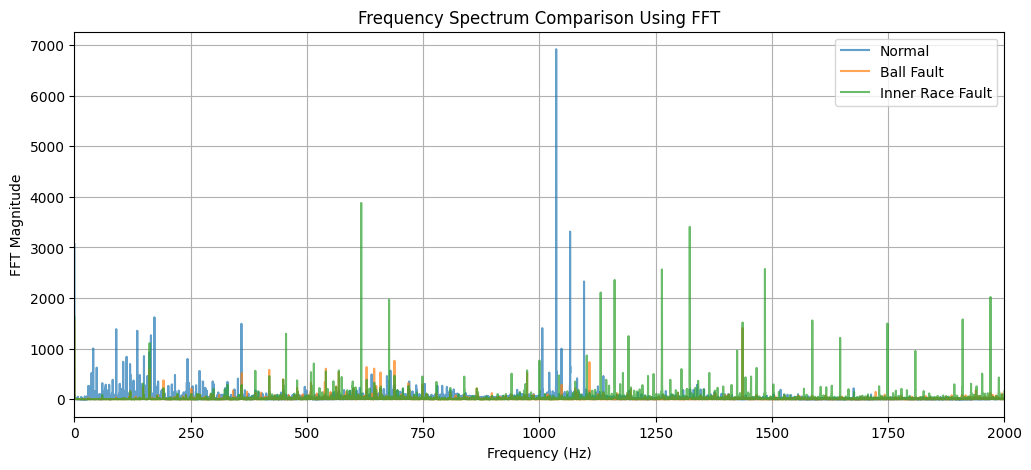

In [ ]:
# ============================================================
# Frequency-Domain Analysis Using Fast Fourier Transform (FFT)
# ============================================================
#
# Time-domain vibration plots show how the signal amplitude changes
# over time. However, many mechanical faults are easier to identify
# in the frequency domain because defects often introduce periodic
# vibration components, harmonics, or energy concentration at specific
# frequency ranges.
#
# The Fast Fourier Transform (FFT) converts the vibration signal from
# the time domain into the frequency domain. This allows us to examine
# how vibration energy is distributed across frequencies.
#
# In condition monitoring, FFT analysis is commonly used to detect:
#   - abnormal frequency peaks
#   - increased harmonic content
#   - fault-related vibration components
#   - changes in spectral energy compared to baseline behavior
#
# Sampling frequency:
# The CWRU drive-end bearing data used in this analysis was collected
# at 12,000 samples per second, so fs = 12000 Hz is used.

from scipy.fft import fft

def compute_fft(signal, fs=12000):
    """
    Compute the single-sided frequency spectrum of a vibration signal.

    Parameters:
        signal (numpy.ndarray):
            One-dimensional vibration signal in the time domain.

        fs (int):
            Sampling frequency in Hz. For the selected CWRU dataset,
            the drive-end vibration signals are sampled at 12 kHz.

    Returns:
        freqs_positive (numpy.ndarray):
            Positive frequency values.

        fft_positive (numpy.ndarray):
            Corresponding FFT magnitude values.
    """

    # Number of samples in the signal
    N = len(signal)

    # Compute FFT magnitude.
    # np.abs() is used because FFT output is complex-valued.
    fft_values = np.abs(fft(signal))

    # Generate frequency bins corresponding to FFT values.
    freqs = np.fft.fftfreq(N, d=1/fs)

    # Keep only the positive half of the frequency spectrum.
    # For real-valued signals, the FFT is symmetric, so the negative
    # half does not add new diagnostic information.
    freqs_positive = freqs[:N // 2]
    fft_positive = fft_values[:N // 2]

    return freqs_positive, fft_positive


# Compute FFT spectra for all three operating conditions.
f_normal, fft_normal = compute_fft(normal_signal)
f_ball, fft_ball = compute_fft(ball_signal)
f_ir, fft_ir = compute_fft(ir_signal)


# Plot frequency-domain comparison.
# The x-axis is limited to 0–2000 Hz to focus on the most relevant
# low-to-mid frequency region where many fault-related vibration
# components are commonly observed.
plt.figure(figsize=(12,5))

plt.plot(f_normal, fft_normal, label='Normal', alpha=0.7)
plt.plot(f_ball, fft_ball, label='Ball Fault', alpha=0.7)
plt.plot(f_ir, fft_ir, label='Inner Race Fault', alpha=0.7)

plt.xlim(0, 2000)
plt.title("Frequency Spectrum Comparison Using FFT")
plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT Magnitude")
plt.legend()
plt.grid(True)

plt.show()

Normal segments: (119, 2048)
Ball fault segments: (59, 2048)
Inner race fault segments: (59, 2048)


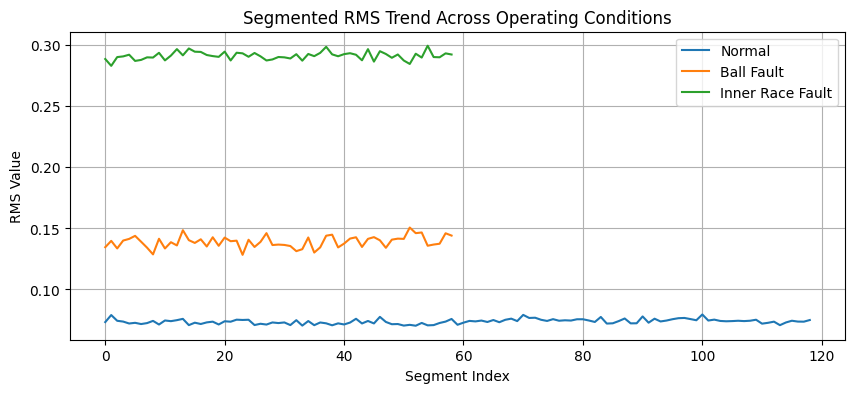

In [ ]:
# ============================================================
# Windowing / Segmentation of Vibration Signals
# ============================================================
#
# In real-world condition monitoring systems, signals are rarely analyzed
# only as one long continuous sequence. Instead, incoming sensor data is
# typically divided into smaller time windows.
#
# Windowing makes the analysis more practical because it allows the system
# to track how diagnostic features evolve over time. This is important for
# early fault detection because degradation often appears gradually as a
# change in feature trends, rather than as one isolated event.
#
# In this project, each vibration signal is divided into non-overlapping
# windows of 2048 samples. Each window is then treated as a short segment
# representing a local operating condition.
#
# Benefits of segmentation:
#   - supports real-time monitoring logic
#   - enables trend analysis
#   - allows feature extraction per time window
#   - prepares the data for machine learning anomaly detection

def segment_signal(signal, window_size=2048):
    """
    Split a vibration signal into fixed-size non-overlapping windows.

    Parameters:
        signal (numpy.ndarray):
            One-dimensional vibration signal.

        window_size (int):
            Number of samples per segment. A window size of 2048
            provides a practical balance between local detail and
            statistical stability.

    Returns:
        numpy.ndarray:
            Two-dimensional array where each row is one signal segment.
    """

    segments = []

    # Iterate through the signal in steps equal to the window size.
    # The final incomplete segment is ignored to maintain equal-length windows.
    for start_idx in range(0, len(signal) - window_size, window_size):
        end_idx = start_idx + window_size
        segment = signal[start_idx:end_idx]
        segments.append(segment)

    return np.array(segments)


# Segment each operating condition.
normal_segments = segment_signal(normal_signal)
ball_segments = segment_signal(ball_signal)
ir_segments = segment_signal(ir_signal)


# Verify the number of segments generated for each condition.
# Each row corresponds to one window; each column corresponds to one sample.
print("Normal segments:", normal_segments.shape)
print("Ball fault segments:", ball_segments.shape)
print("Inner race fault segments:", ir_segments.shape)


# Compute RMS value for each segment.
# Segment-level RMS allows us to observe changes in vibration energy
# over time rather than relying only on one global RMS value.
def compute_rms_segments(segments):
    """
    Compute RMS values for each signal segment.

    Parameters:
        segments (numpy.ndarray):
            Two-dimensional array of signal windows.

    Returns:
        list:
            RMS value for each segment.
    """

    return [np.sqrt(np.mean(segment**2)) for segment in segments]


rms_normal_segments = compute_rms_segments(normal_segments)
rms_ball_segments = compute_rms_segments(ball_segments)
rms_ir_segments = compute_rms_segments(ir_segments)


# Plot RMS trend over segmented windows.
# This graph approximates how a monitoring system could track vibration
# energy over time and identify abnormal increases.
plt.figure(figsize=(10,4))

plt.plot(rms_normal_segments, label='Normal')
plt.plot(rms_ball_segments, label='Ball Fault')
plt.plot(rms_ir_segments, label='Inner Race Fault')

plt.title("Segmented RMS Trend Across Operating Conditions")
plt.xlabel("Segment Index")
plt.ylabel("RMS Value")
plt.legend()
plt.grid(True)

plt.show()

ML-based anomaly detection results:
Normal anomalous segments: 6
Ball fault anomalous segments: 59
Inner race fault anomalous segments: 59


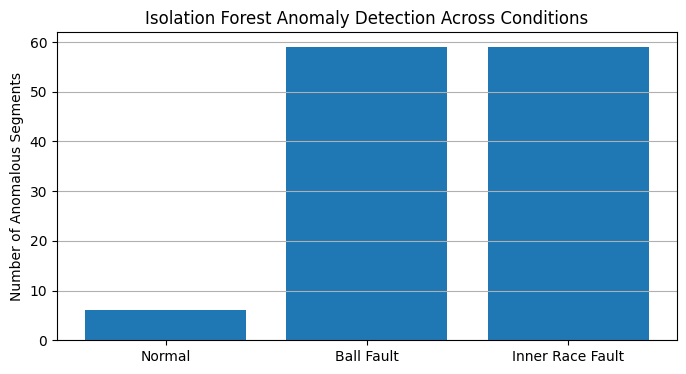

In [ ]:
# ============================================================
# Machine Learning-Based Anomaly Detection Using Isolation Forest
# ============================================================
#
# The previous anomaly detection method used a manually defined threshold:
#     threshold = 2 × RMS(normal)
#
# While this approach is simple and interpretable, real-world systems often
# benefit from machine learning methods that learn the baseline behavior
# directly from data.
#
# Isolation Forest is an unsupervised anomaly detection algorithm. It is
# useful when labeled fault data is limited or unavailable, which is common
# in infrastructure and industrial monitoring applications.
#
# In this project, the model is trained only on the normal baseline RMS
# segment values. The goal is to learn what normal vibration energy looks
# like. The trained model is then applied to normal, ball fault, and inner
# race fault conditions.
#
# Output interpretation:
#   +1 = normal / inlier
#   -1 = anomaly / outlier
#
# This approach is realistic for early-stage condition monitoring because
# collecting normal data is usually easier than collecting large quantities
# of labeled failure data.

from sklearn.ensemble import IsolationForest


# Prepare training data using only normal-condition RMS values.
# The model learns the distribution of normal vibration energy.
#
# reshape(-1, 1) is required because scikit-learn expects a 2D input matrix:
# rows = samples, columns = features.
X_train = np.array(rms_normal_segments).reshape(-1, 1)


# Create the Isolation Forest model.
#
# contamination=0.05 means the model expects approximately 5% of training
# samples to behave like outliers. This is a conservative starting value
# for baseline monitoring.
#
# random_state ensures reproducible results.
model = IsolationForest(
    contamination=0.05,
    random_state=42
)


# Train the model using only normal baseline behavior.
model.fit(X_train)


# Prepare test data for all three conditions.
X_normal = np.array(rms_normal_segments).reshape(-1, 1)
X_ball = np.array(rms_ball_segments).reshape(-1, 1)
X_ir = np.array(rms_ir_segments).reshape(-1, 1)


# Predict anomalies for each operating condition.
# The model assigns:
#   +1 to normal-like segments
#   -1 to anomalous segments
pred_normal = model.predict(X_normal)
pred_ball = model.predict(X_ball)
pred_ir = model.predict(X_ir)


# Count the number of anomalous segments detected in each condition.
normal_ml_anomalies = np.sum(pred_normal == -1)
ball_ml_anomalies = np.sum(pred_ball == -1)
ir_ml_anomalies = np.sum(pred_ir == -1)


print("ML-based anomaly detection results:")
print("Normal anomalous segments:", normal_ml_anomalies)
print("Ball fault anomalous segments:", ball_ml_anomalies)
print("Inner race fault anomalous segments:", ir_ml_anomalies)


# Visualize ML anomaly counts across operating conditions.
# A higher number of anomalous segments in fault conditions indicates that
# the model trained on normal behavior can detect deviations caused by faults.
conditions = ["Normal", "Ball Fault", "Inner Race Fault"]
ml_anomaly_counts = [
    normal_ml_anomalies,
    ball_ml_anomalies,
    ir_ml_anomalies
]

plt.figure(figsize=(8,4))
plt.bar(conditions, ml_anomaly_counts)

plt.title("Isolation Forest Anomaly Detection Across Conditions")
plt.ylabel("Number of Anomalous Segments")
plt.grid(axis='y')

plt.show()